In [38]:
import pandas as pd
from CCA_utils import *

## Baseline Model Panel

In [39]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()
cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)

T=1.0
vol_window = 12
freq = 'ME'

cca_panel_df['domestic_rate_in_units'] = cca_panel_df['domestic_rate_in_units']/100
cca_panel_df['risk_free_rate'] = cca_panel_df['risk_free_rate']/100
cca_panel_df['monetary_base_mn_localcurr'] = cca_panel_df['monetary_base_mn_localcurr'] / 1000
cca_panel_df['domestic_debt_bn_localcurr'] = cca_panel_df['domestic_debt_bn_localcurr']
cca_panel_df['external_debt_mn_usd'] = cca_panel_df['external_debt_mn_usd']/1000

## M2 Specific data

In [40]:

ovx_df = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')
ovx_df['date'] = pd.to_datetime(ovx_df['date'])

cca_panel_df = cca_panel_df.merge(ovx_df[['date','OVXCLS']], on='date', how='left')

beta = 1
n_paths=5000 #Number of paths for the montecarlo jump simulation
seed = 42
ovxqtl = 0.85

def ovx_to_jump_params(ovx, beta):
    if ovx < 30: return (0.0, 0.0, 0.0)
    if ovx < 50:  lam, mu, sig = 0.019, -0.0625, 0.0112
    elif ovx < 70: lam, mu, sig = 0.031, -0.0646, 0.0186
    elif ovx < 100: lam, mu, sig = 0.210, -0.0750, 0.0232
    else:           lam, mu, sig = 0.634, -0.1329, 0.1128

    return (lam, mu * beta, sig * beta)

cca_panel_df.set_index(['date','country'], inplace=True)
cca_panel_df = (
    cca_panel_df
    .groupby('country')
    .resample('ME', level='date')
    .last()
)
cca_panel_df.reset_index(inplace=True)
cca_panel_df

,country,date,Unnamed: 0,year,quarter,month,week,cds_spread,msci_index,monetary_base_mn_localcurr,domestic_debt_bn_localcurr,external_debt_mn_usd,domestic_rate_in_units,risk_free_rate,fx_rate,OVXCLS
0,Abu Dhabi,2014-01-31,13780,2014,1.0,1.0,5.0,56.32999,804.960,288.310000,210.154,22.889480,0.01,0.0010,3.672960,20.35
1,Abu Dhabi,2014-02-28,13784,2014,1.0,2.0,9.0,54.78999,867.273,287.846000,210.154,22.889480,0.01,0.0012,3.672960,18.71
2,Abu Dhabi,2014-03-31,13788,2014,1.0,3.0,13.0,53.81999,895.321,297.840000,210.154,22.889480,0.01,0.0013,3.672960,19.15
3,Abu Dhabi,2014-04-30,13792,2014,2.0,4.0,17.0,51.34000,1030.704,293.257000,210.154,22.889480,0.01,0.0011,3.673095,18.88
4,Abu Dhabi,2014-05-31,13797,2014,2.0,5.0,22.0,44.79999,1043.794,296.941000,210.154,22.889480,0.01,0.0010,3.672960,15.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,Turkey,2024-08-31,13184,2024,3.0,8.0,35.0,265.75000,613.356,6157.194895,10716.668,157.127935,0.50,0.0438,34.071550,33.36
2240,Turkey,2024-09-30,13188,2024,3.0,9.0,39.0,267.87010,631.258,6175.969703,10716.668,157.127935,0.50,0.0390,34.129693,39.62
2241,Turkey,2024-10-31,13192,2024,4.0,10.0,43.0,271.25000,550.218,6099.357409,10716.668,157.127935,0.50,0.0429,34.246575,48.97
2242,Turkey,2024-11-30,13197,2024,4.0,11.0,48.0,251.12000,610.455,6067.888530,10716.668,157.127935,0.50,0.0430,34.722222,34.95


In [41]:
pricer = JumpDiffusionPricer(steps=12, n_paths=n_paths)

results = pd.DataFrame()
for country, group in cca_panel_df.groupby('country'):
    df = group.copy().sort_values('date').reset_index(drop=True)
    
    r_d = df['domestic_rate_in_units']
    r_f = df['risk_free_rate']
    M_bn = df['monetary_base_mn_localcurr']
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd']
    fx_rate = df['fx_rate']

    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(M_bn, dom_D_bn, fx_rate, r_d, r_f)
    ]

    ann_factor = np.sqrt(12)
    log_ret = np.log(df['LCL_usd'] / df['LCL_usd'].shift(1))
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor
    
    df['B_f'] = [
        compute_barrier_kvm(debt, rf, T)
        for debt, rf in zip(ext_D_bn, r_f)
    ]

    out = {'implied_V': [], 'implied_sigma_V': [], 'cca_converged': [],
           'distance_to_distress': [], 'default_prob': [],
           'model_spread_bps': [], 'put_value': [], 'risky_debt': [],
           'leverage': []}
    
    for i, row in df.iterrows():
        lam_i, mu_J_i, sigma_J_i = ovx_to_jump_params(row['OVXCLS'],beta=beta)

        cca_base = solve_CCA(row['LCL_usd'], row['sigma_lcl'], row['B_f'],
                             r_f.iloc[i], T)
        
        if lam_i == 0:
            risk = compute_risk(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                                r_f.iloc[i], T)
        else:   
            risk = pricer.compute_risk_jd(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                                          r_f.iloc[i], T,
                                          lam=lam_i, mu_J=mu_J_i, sigma_J=sigma_J_i,
                                          seed=42)

        out['implied_V'].append(cca_base['V'])
        out['implied_sigma_V'].append(cca_base['sigma_V'])
        out['cca_converged'].append(cca_base['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals
           
    results = pd.concat([results, df])


START_DATE = '2015-01-01'
END_DATE = '2024-12-31'

results = results[
    (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
].copy()


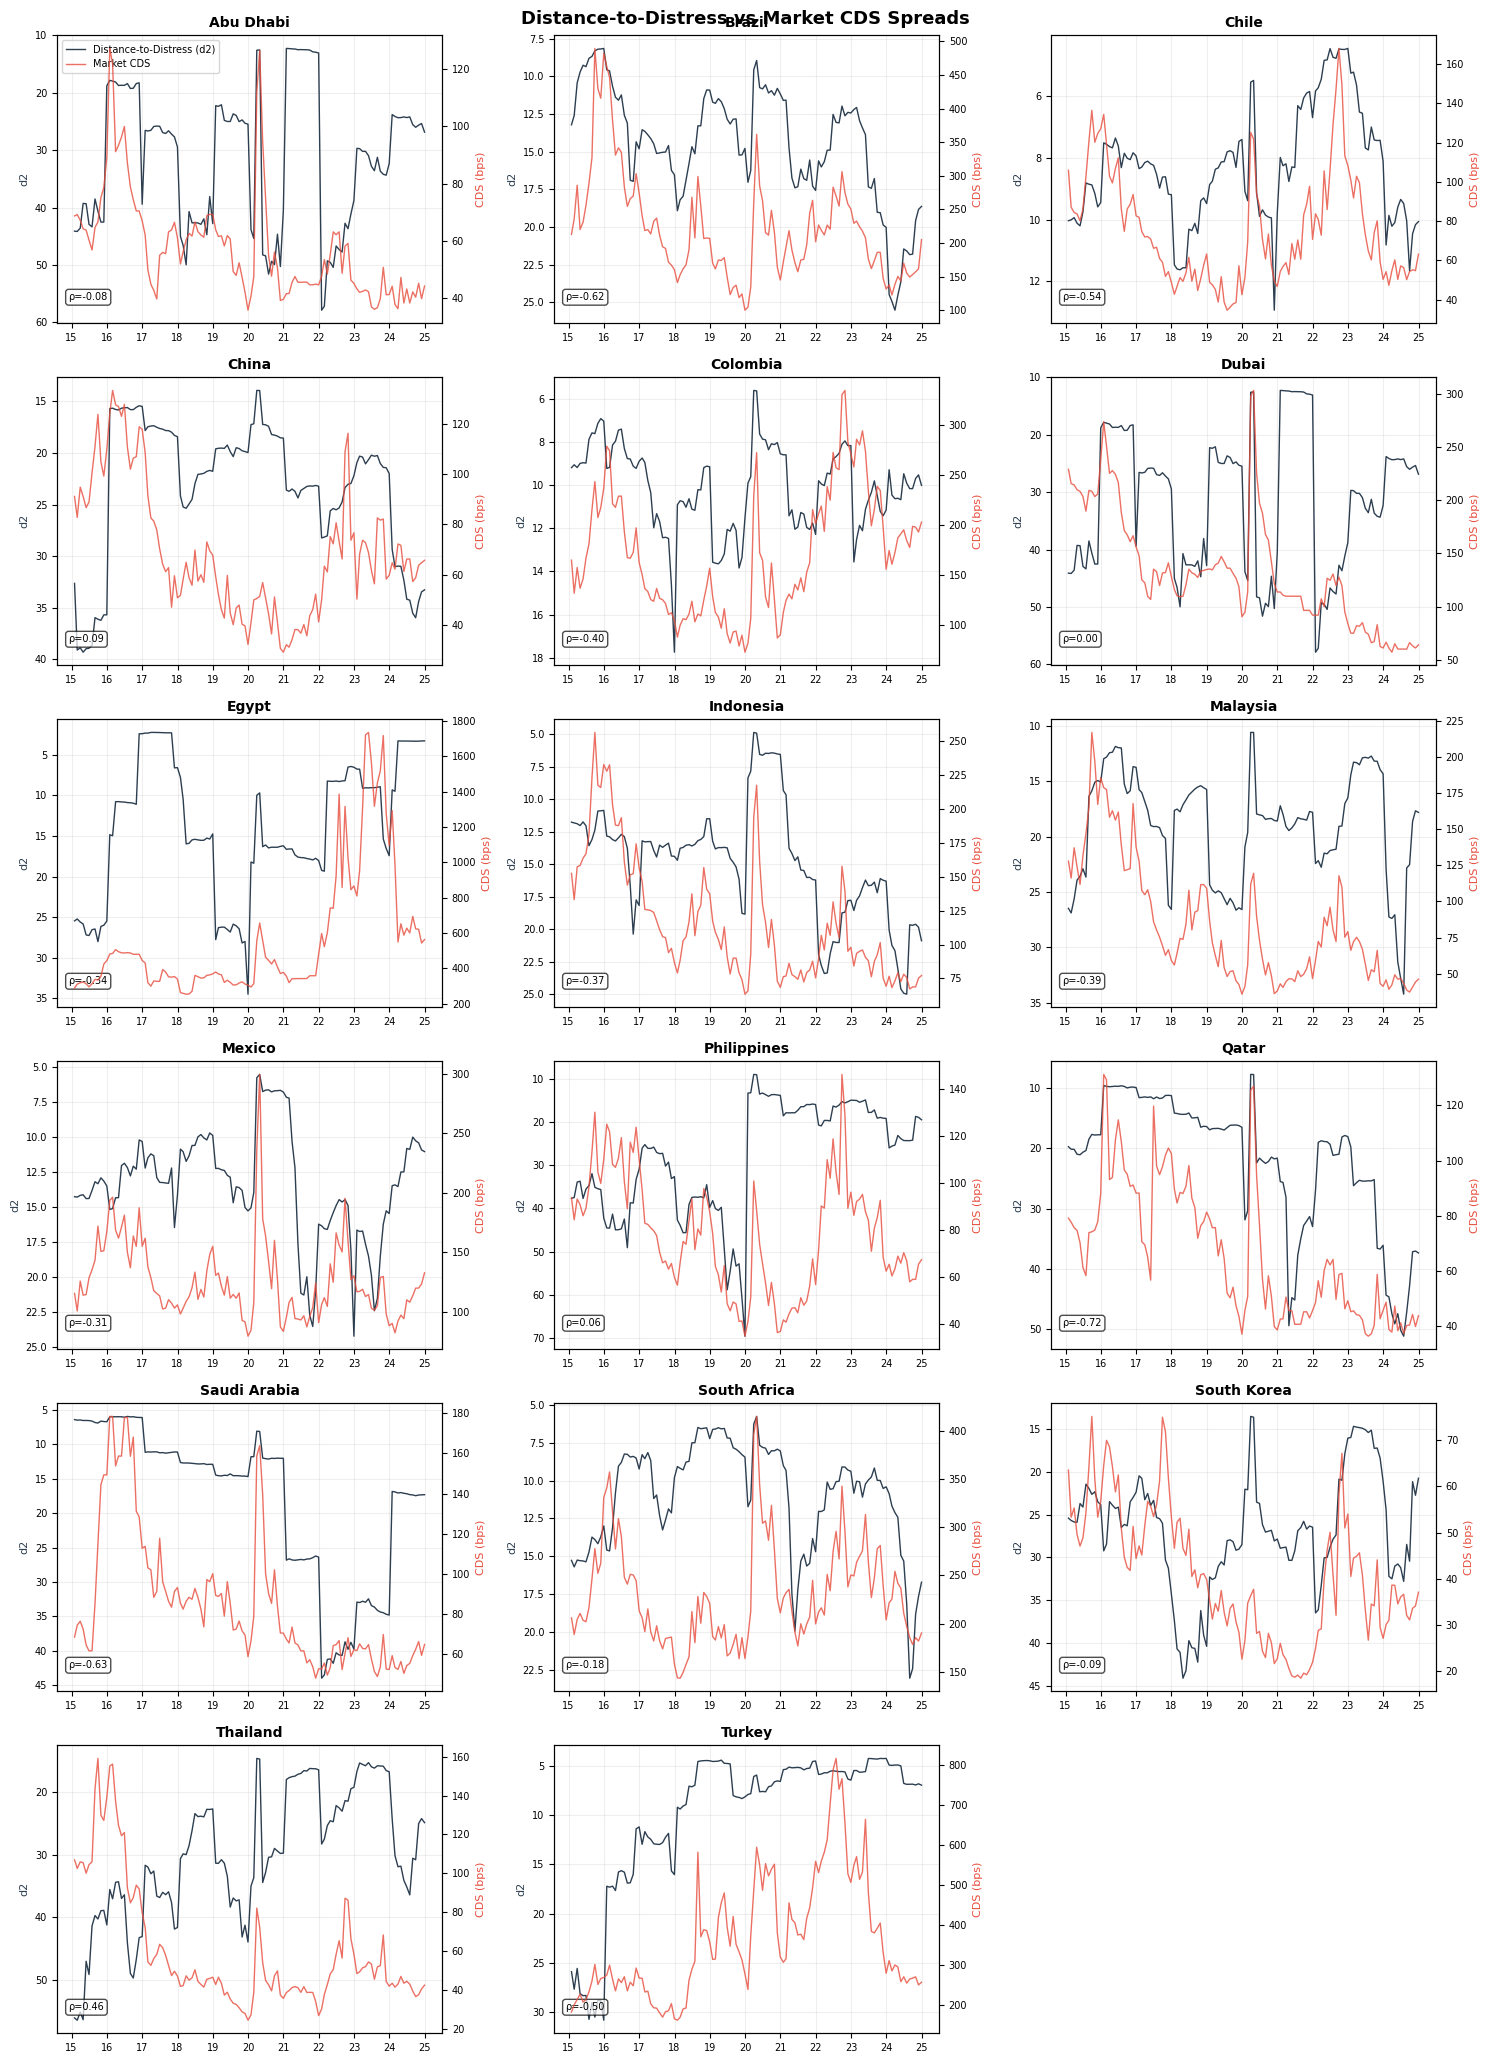

In [43]:
d2_vs_cds = plot_d2_vs_cds(results)

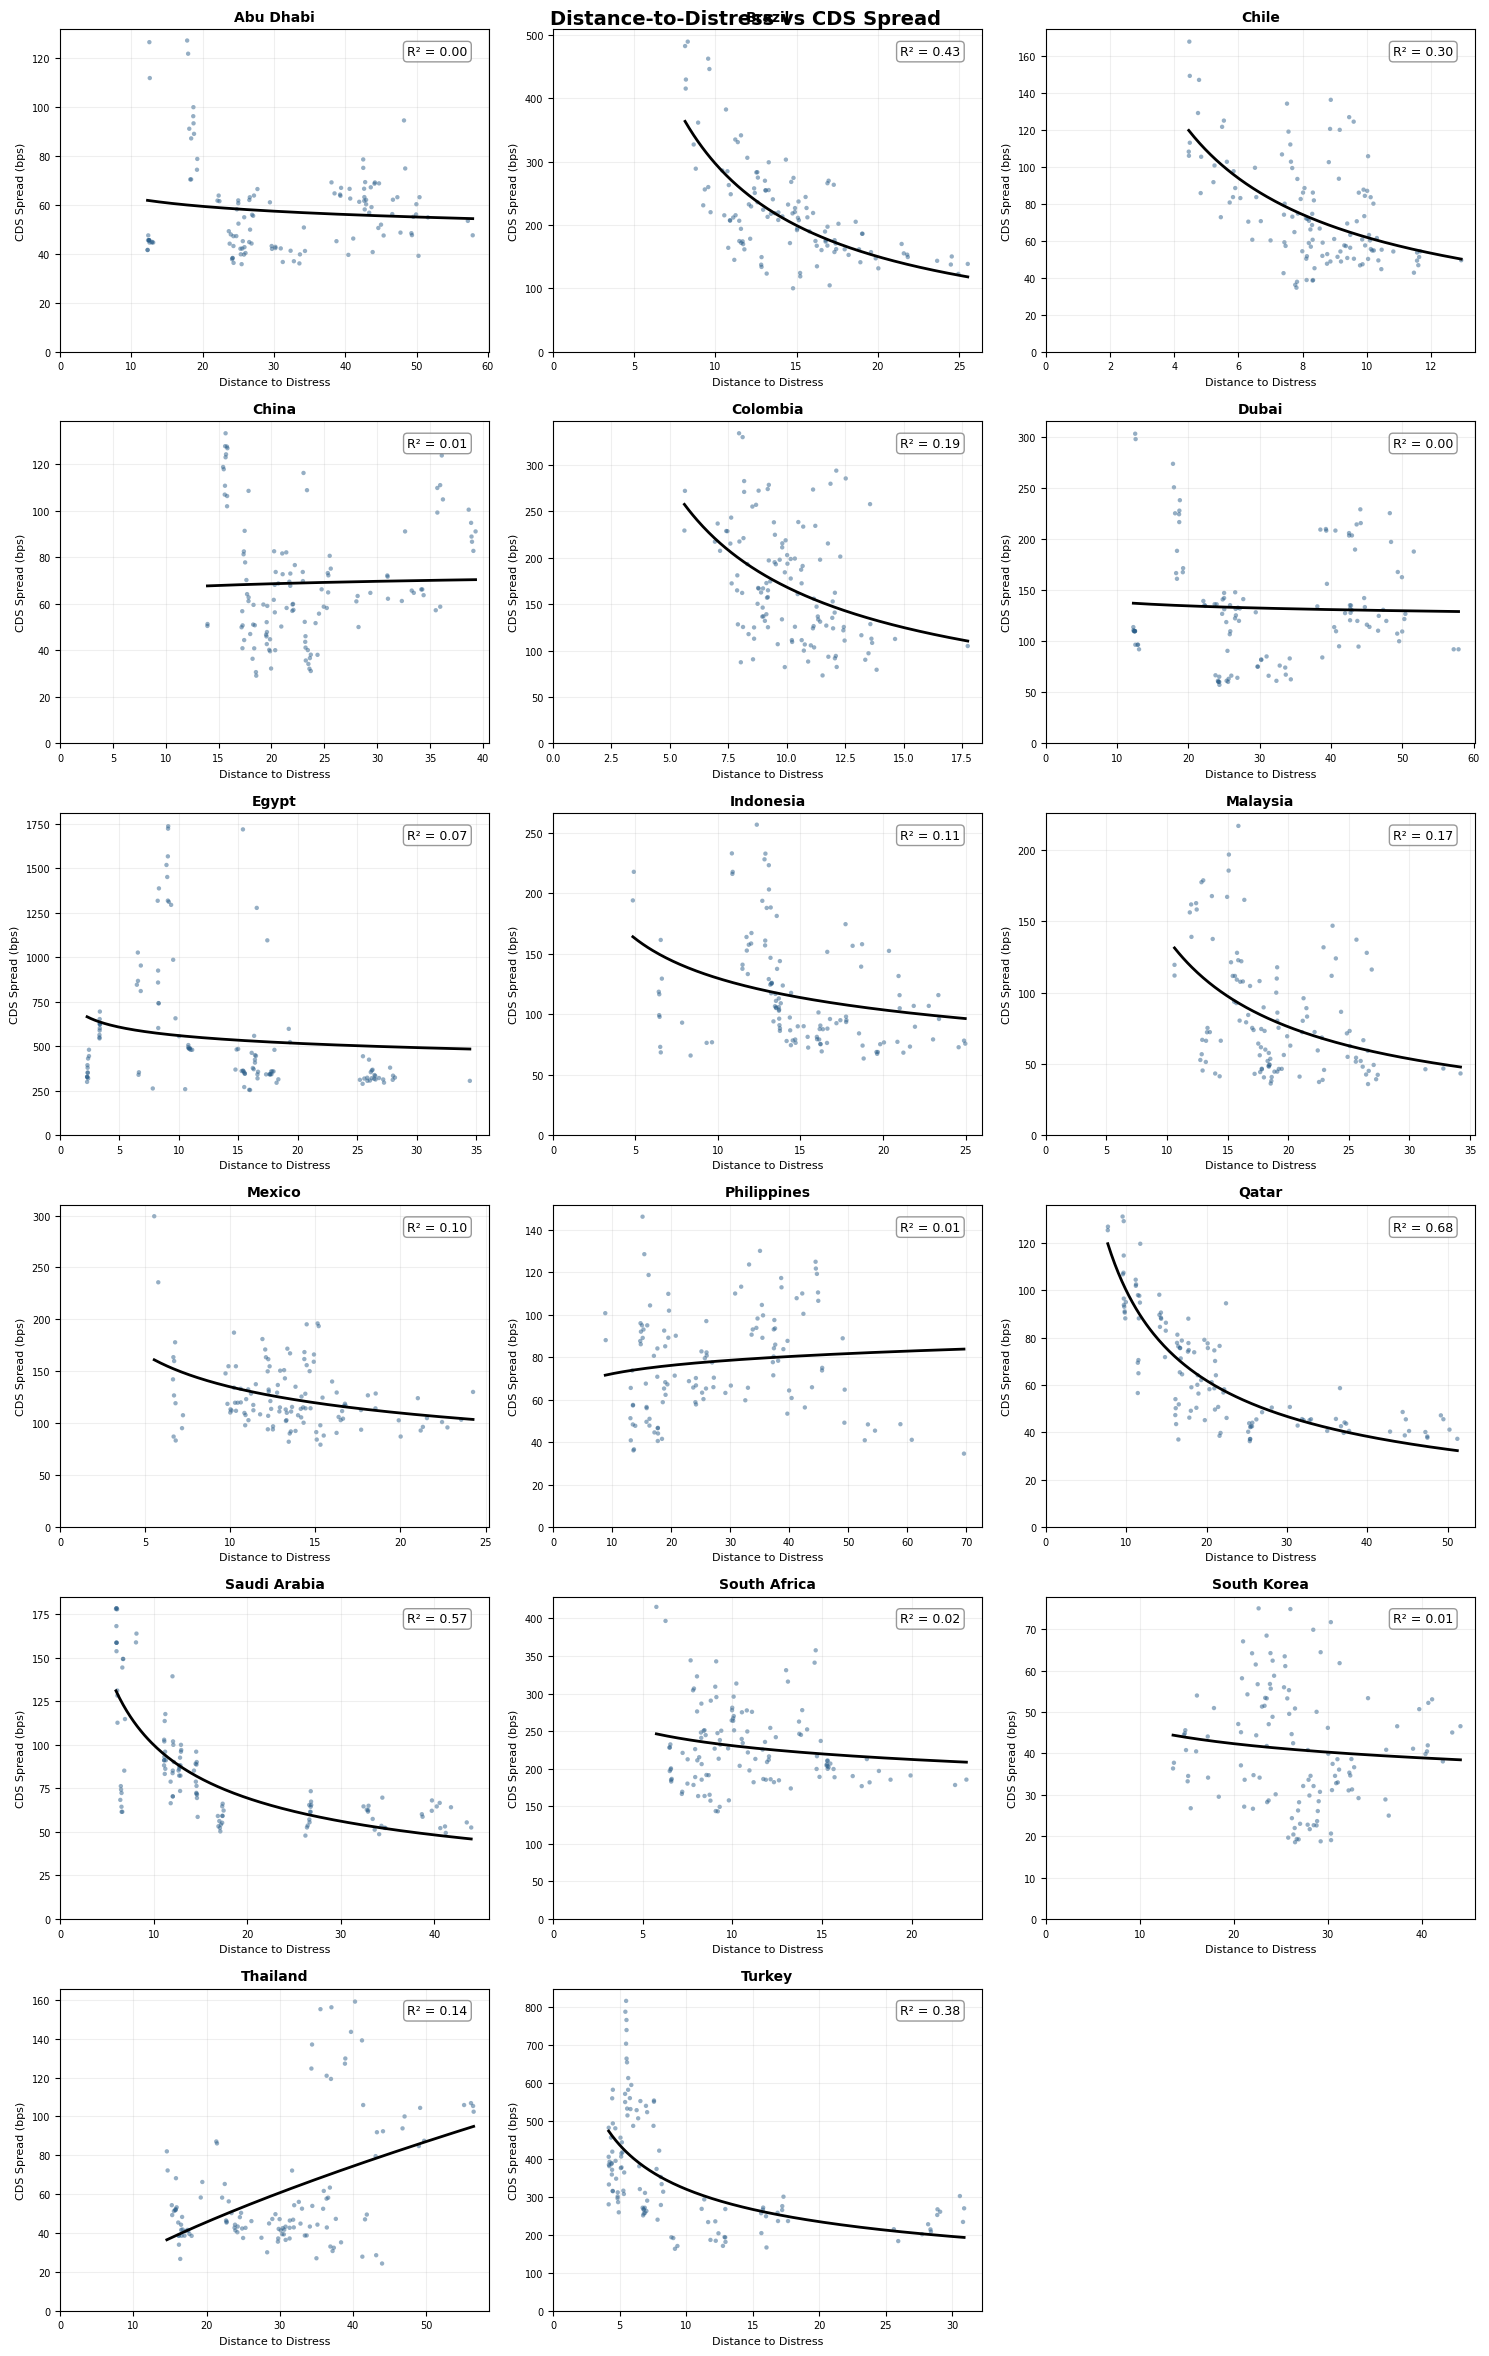

In [44]:
d2_scatter = plot_d2_scatter(results)

In [45]:
display, raw = correlation_table(
    results,
    dd_col='distance_to_distress',
    horizons=[1, 3, 6],
    horizon_labels=['1m', '3m', '6m'],
)
display

,Country,N,ρ (1m),ρ_S (1m),Dir (1m),ρ (3m),ρ_S (3m),Dir (3m),ρ (6m),ρ_S (6m),Dir (6m)
0,Abu Dhabi,120,-0.35***,-0.00,49%,-0.35***,-0.09,48%,-0.15,-0.05,51%
1,Brazil,120,-0.41***,-0.43,69%,-0.48***,-0.42,68%,-0.54***,-0.56,83%
2,Chile,120,-0.37***,-0.27,55%,-0.45***,-0.48,71%,-0.46***,-0.44,71%
3,China,120,-0.14,-0.20,60%,-0.24**,-0.25,62%,-0.25***,-0.26,63%
4,Colombia,120,-0.22**,-0.17,58%,-0.30***,-0.20,56%,-0.44***,-0.39,65%
5,Dubai,120,-0.47***,-0.07,60%,-0.34***,-0.14,57%,-0.09,-0.12,57%
6,Egypt,120,-0.01,-0.07,48%,0.02,-0.03,50%,-0.05,-0.16,55%
7,Indonesia,120,-0.10,-0.13,58%,-0.21**,-0.07,50%,-0.29***,-0.21,61%
8,Malaysia,120,-0.28***,-0.29,61%,-0.46***,-0.42,64%,-0.48***,-0.45,61%
9,Mexico,120,-0.26***,-0.15,55%,-0.41***,-0.30,65%,-0.34***,-0.40,69%


In [9]:
results.to_csv("../output/results/M2_results.csv")